# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [ ]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import matplotlib.animation as animation
import seaborn as sns

import model_ricard as m       # I've put all the functions in a separate Python file

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 22
})


(ipykernel_launcher.py:16674): dbind-WARNING **: 10:11:42.778: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_flip': 0.1,                         # probability of bitflipping an element in C
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 500,                                   # temperature parameter for the softmax 
     'crossover_ratio': 0.6,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': None,                       # output = np.mean(state[int(par['majority_ratio']*par['L']):-1]); if None, output = state[-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.05,           # standard deviation of the normal distribution used to sample the mutation value for T = T_mutation_radius * L
     'reproduction_ratio': 0.4,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.4,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 500,                    # number of iterations of the algorithm
     'early_stop_ratio': 0.9,           # ratio of solutions to have loss < 0.01 for early stop to trigger
     'rndm_gen_stop': 0.1,                  # best target distance lower threshold for halting random generation
     'add_weights': 0.05,                    # best loss lower threshold for adding the weights cost to the loss function
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

nrd.seed(1234)

In [ ]:
solutions, lmean, mean_t_dist, mean_weight_cost, loss_ev, mean_asp,T_values, mean_volume, mean_weight, t_full_loss = m.evolution(par,verb=1,gen_verb=False,stat=True,early_stop=True)

Iteration #0...
Mean loss: 1.0000280220879971
Best loss: 1.0
Cumulative Best loss: 1.0
Best target distance: 1.0
Mean target distance: 1.0000280220879971
Mean volume: 0.89986328125
Mean Weight:-0.028131888113486738
Iteration #100...
Mean loss: 1.0000493049044936
Best loss: 0.999998630861389
Cumulative Best loss: 0.999998630861389
Best target distance: 1.0
Mean target distance: 1.0000493049044936
Mean volume: 0.88345703125
Mean Weight:-0.02413069899725226
Iteration #200...
Mean loss: 0.5431003012073073
Best loss: 0.1512273429895138
Cumulative Best loss: 0.2374652036842224
Best target distance: 1.5087113121519826
Mean target distance: 0.5431003012073073
Mean volume: 0.5757421875
Mean Weight:0.9497518021670337
####################### Task solved after 208 iterations. Now weights cost is introduced. ###########################
####################### Random generation stopped at iteration #220 ###########################
Iteration #300...
Mean loss: 0.5051686054810514
Best loss: 0.10544475

In [4]:
losses = []
for n,sol in enumerate(solutions[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.9332702350164812
Target distance:0.004452861534755651
Input: [-1, 1] -> Output: 0.9979156595455545
Target distance:4.34447513003807e-06
Input: [1, -1] -> Output: 0.9994703154008218
Target distance:2.805657746066099e-07
Input: [1, 1] -> Output: -0.4134152976909542
Target distance:0.3440816129829919
loss:0.08713477488966305
Solution #1
Input: [-1, -1] -> Output: -0.9550439715025809
Target distance:0.002021044498260757
Input: [-1, 1] -> Output: 0.8037600504853413
Target distance:0.03851011778551581
Input: [1, -1] -> Output: 0.7737411420451081
Target distance:0.05119307080305194
Input: [1, 1] -> Output: -0.9990963376466498
Target distance:8.166056488623389e-07
loss:0.022931262423119343
Solution #2
Input: [-1, -1] -> Output: -0.3590964471821424
Target distance:0.4107573640145524
Input: [-1, 1] -> Output: -0.3905191934178187
Target distance:1.933543627263341
Input: [1, -1] -> Output: 0.999822929555233
Target distance:3.135394240998405e-08
Input: [1, 

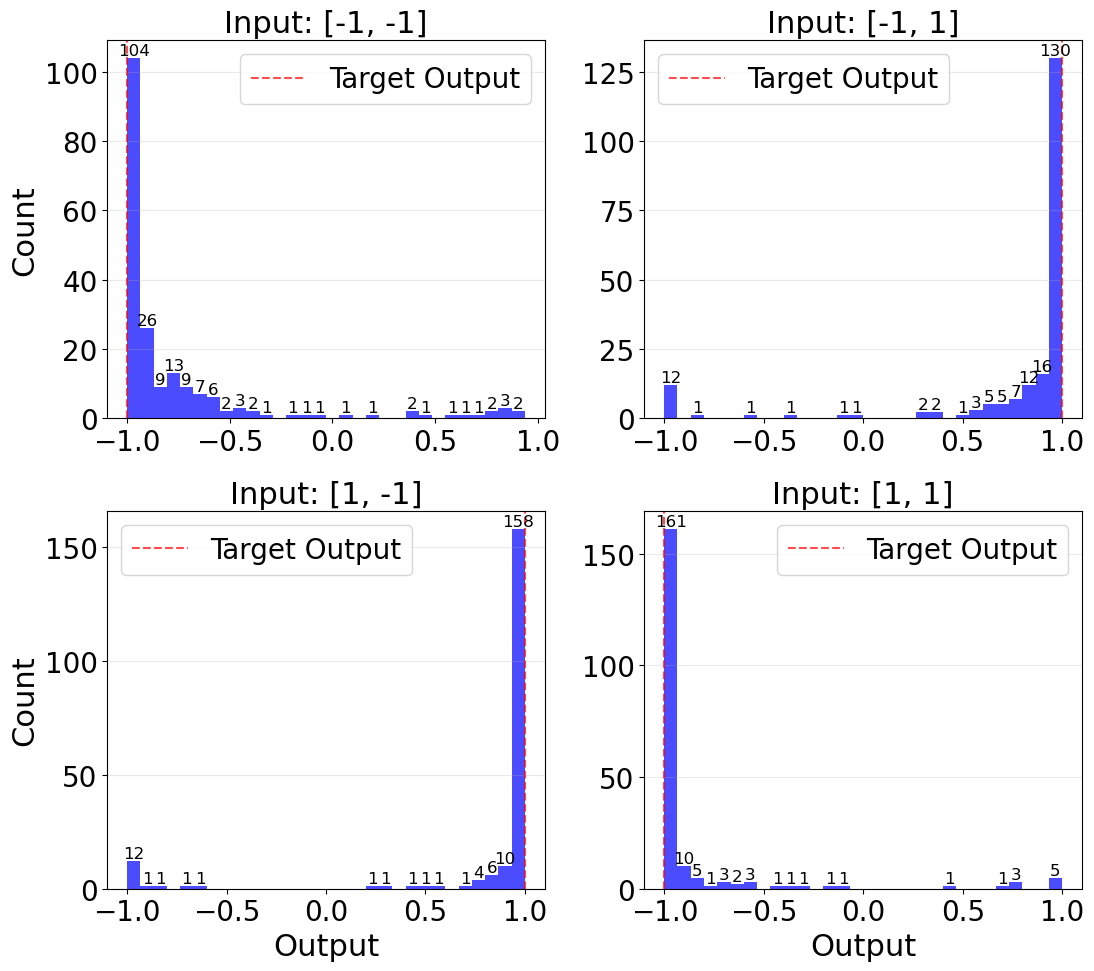

In [5]:
outputs = np.zeros((len(solutions), len(par['input_set'])))
for n, sol in enumerate(solutions):
    for i, input in enumerate(par['input_set']):
        output = m.ff(input, sol, par)
        outputs[n, i] = output

fig, axes = plt.subplots(2, len(par['input_set']) // 2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]}')
    ax.axvline(par['target_set'][i], label='Target Output', color='r', linestyle='--',alpha=0.7)
    if i > 1:
        ax.set_xlabel('Output')
    if i%2==0:
        ax.set_ylabel('Count')
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=12)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"crossover_ratio = {par['crossover_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

'''
# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
'''

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/IO.png')
plt.show()
plt.close(fig)

Links density:0.421875


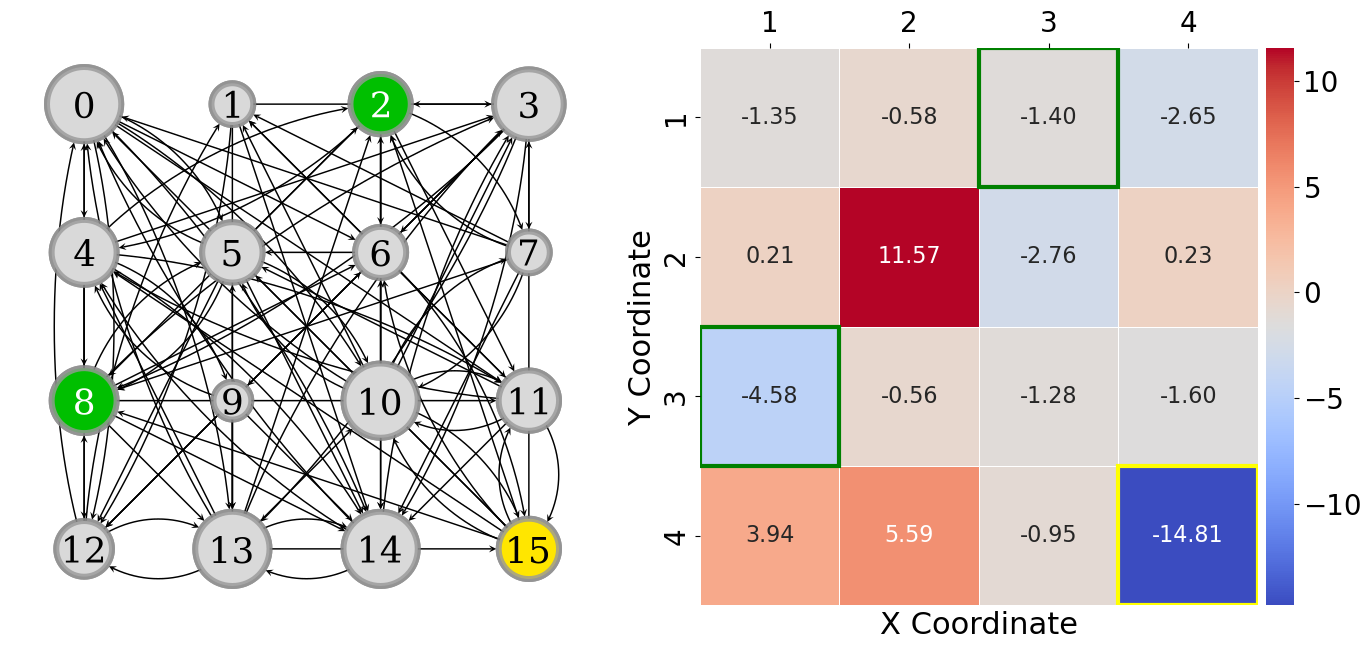

In [35]:
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

print(f'Links density:{np.sum(solutions[n].C)/solutions[n].C.shape[0]**2}')

best = solutions[(np.argmin([s.loss for s in solutions]))]
graph = best.G
highlight = graph.new_vertex_property('vector<double>')

# default color for all nodes (light gray)
for v in graph.vertices():
    highlight[v] = [0.85, 0.85, 0.85, 1.0]

# input nodes -> green
input_indices = [par['L']//2, 2*par['L']]
for idx in input_indices:
    highlight[graph.vertex(idx)] = [0.0, 0.75, 0.0, 1.0]

# output node(s) -> yellow
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio'] * (par['L']**2)), graph.num_vertices()):
        highlight[graph.vertex(i)] = [1.0, 0.9, 0.0, 1.0]
else:
    highlight[graph.vertex(par['L']**2 - 1)] = [1.0, 0.9, 0.0, 1.0]

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Graph plot: fixed square-lattice layout ordered by vertex index
pos = graph.new_vertex_property("vector<double>")
for idx in range(graph.num_vertices()):
    row, col = divmod(idx, par['L'])          # index order: left->right, top->bottom
    pos[graph.vertex(idx)] = [col, par['L'] - 1 - row]  # flip y to match heatmap orientation

# vertex size proportional to node degree
deg = graph.degree_property_map("total")
deg_vals = np.array([deg[v] for v in graph.vertices()], dtype=float)

vertex_size = graph.new_vertex_property("double")
dmin, dmax = deg_vals.min(), deg_vals.max()

for v in graph.vertices():
    if dmax > dmin:
        #vertex_size[v] = 0.8 * (deg[v] - dmin) / (dmax - dmin)
        vertex_size[v] = 0.5*deg[v] / dmax
    else:
        vertex_size[v] = 0.8

graph_draw(
    graph,
    pos=pos,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vertex_size=vertex_size,
    vcmap=plt.cm.Set1,
    mplfig=ax[0],
    edge_color='black',
    edge_pen_width=0.01,
    edge_marker_size=0.05,
    fit_view=False
)

# enforce lattice framing
ax[0].set_xlim(-0.5, par['L'] - 0.5)
ax[0].set_ylim(-0.5, par['L'] - 0.5)
ax[0].set_aspect('equal')
ax[0].set_axis_off()

# Prepare mask for highlighting input and output cells
mask = np.zeros((par['L'], par['L']), dtype=bool)
highlight_colors = np.full((par['L'], par['L']), '', dtype=object)
input_indices = [par['L']//2, 2*par['L']]
output_index = par['L']**2 - 1
for idx in input_indices:
    y, x = divmod(idx, par['L'])
    highlight_colors[y, x] = 'input'
y, x = divmod(output_index, par['L'])
highlight_colors[y, x] = 'output'

# Heatmap plot
# create a dedicated colorbar axis with the same height as the heatmap axis
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.08)

sns.heatmap(
    solutions[n].T.reshape(par['L'], par['L']),
    xticklabels=np.arange(1, par['L'] + 1),
    yticklabels=np.arange(1, par['L'] + 1),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    vmin=np.min(solutions[n].T),
    vmax=np.max(solutions[n].T),
    ax=ax[1],
    cbar=True,
    cbar_ax=cax
)

ax[1].set(xlabel="X Coordinate", ylabel="Y Coordinate")
# ax[1].set_title('Gain Parameter Distribution of Solution')
ax[1].xaxis.tick_top()
ax[1].set_aspect('equal')

for (y, x), label in np.ndenumerate(highlight_colors):
    if label == 'input':
        ax[1].add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='green', lw=3))
    elif label == 'output':
        ax[1].add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='yellow', lw=3))

'''
fig.text(0.72, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
'''

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig(f'plots/graph_sol_best.png')
#plt.close(fig)

In [7]:
sol = sorted(solutions, key=lambda sol: sol.loss)
for i,input in enumerate(par['input_set']):
    output = m.ff(input,sol[0],par,verb=0)
    print(f'Input:{input} -> Output:{output} -- Expected:{par['target_set'][i]}')

Input:[-1, -1] -> Output:-0.96539427401428 -- Expected:-1.0
Input:[-1, 1] -> Output:0.9530087602198276 -- Expected:1.0
Input:[1, -1] -> Output:0.9515172565796817 -- Expected:1.0
Input:[1, 1] -> Output:-0.999977932658833 -- Expected:-1.0


In [8]:
'''
data = np.mean(T_values,axis=0)

fig, ax = plt.subplots(figsize=(8, 6))

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Move parameter box to the right and center vertically
fig.text(0.98, 0.5, param_text, fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Use fixed bins for all frames to ensure visibility
bins = np.linspace(np.min(data), np.max(data), 50)

def animate(i):
    ax.clear()
    ax.hist(data[:, i], bins=bins, color='b', alpha=0.7)
    ax.set_title(f'Mean Gain Histogram at Iteration {i+1}')
    ax.set_xlabel('Gain')
    ax.set_ylabel('Cells Population')
    ax.set_xlim(np.min(data), np.max(data))
    ax.set_ylim(0, par['L']**2)

ani = animation.FuncAnimation(fig, animate, frames=data.shape[1], interval=50)

ani.save('plots/gain_evolution.gif', writer='pillow')
plt.close(fig)
'''

'\ndata = np.mean(T_values,axis=0)\n\nfig, ax = plt.subplots(figsize=(8, 6))\n\nparam_text = (\n    f"L = {par[\'L\']}\n"\n    f"N_sol = {par[\'N_sol\']}\n"\n    f"n_iter = {par[\'n_iter\']}\n"\n    f"C_density = {par[\'C_density\']}\n"\n    f"tau = {par[\'tau\']}\n"\n    f"reproduction_ratio = {par[\'reproduction_ratio\']}\n"\n    f"elitist_ratio = {par[\'elitist_ratio\']}\n"\n    f"ff_iter = {par[\'ff_iter\']}\n"\n    f"J_mutation_radius = {par[\'J_mutation_radius\']}\n"\n    f"B_mutation_radius = {par[\'B_mutation_radius\']}\n"\n    f"T_mutation_radius = {par[\'T_mutation_radius\']}"\n)\n\n# Move parameter box to the right and center vertically\nfig.text(0.98, 0.5, param_text, fontsize=12, va=\'center\', ha=\'right\',\n         bbox=dict(boxstyle=\'round\', facecolor=\'wheat\', alpha=0.5))\n\n# Use fixed bins for all frames to ensure visibility\nbins = np.linspace(np.min(data), np.max(data), 50)\n\ndef animate(i):\n    ax.clear()\n    ax.hist(data[:, i], bins=bins, color=\'b\', alph

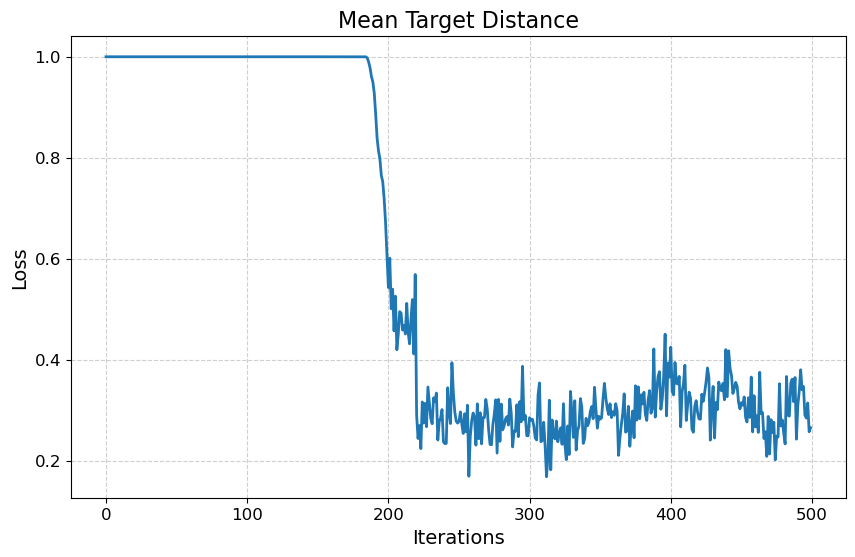

In [9]:
plt.figure(figsize=(10,6))
plt.plot(mean_t_dist, color='tab:blue', linewidth=2)
plt.title('Mean Target Distance', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=12)

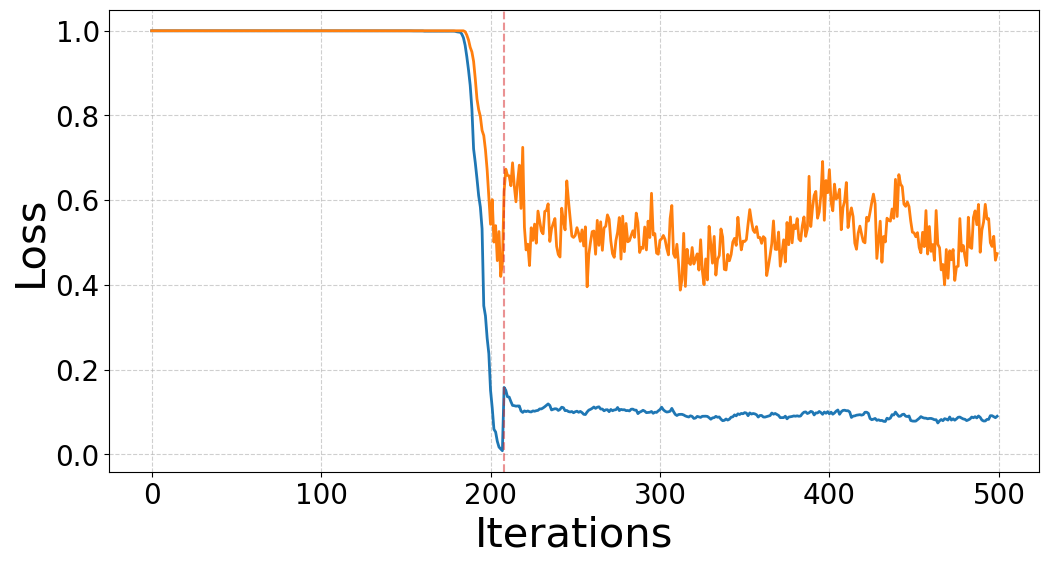

In [ ]:
plt.figure(figsize=(12, 6))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
plt.plot(best_loss, color='tab:blue', linewidth=2,label='Best')
plt.plot(lmean, color='tab:orange', linewidth=2,label='Mean')
plt.axvline(t_full_loss,c='tab:red',linestyle='--',alpha=0.5)
#plt.set_title('Best Loss')
plt.xlabel('Iterations',fontsize=30)
plt.ylabel('Loss',fontsize=30)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both')

'''
# Mean weight Evolution
axs[2, 0].plot(mean_weight, color='tab:brown', linewidth=2)
axs[2, 0].set_title('Mean Weight Evolution')
axs[2, 0].set_xlabel('Iterations')
axs[2, 0].set_ylabel('Mean Weight')
axs[2, 0].grid(True, alpha=0.6)
axs[2, 0].tick_params(axis='both')


# Parameter box in the last (empty) subplot
axs[2, 1].axis('off')
axs[2, 1].text(
    0, 1, param_text, fontsize=13, va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), transform=axs[2, 1].transAxes
)
'''

plt.savefig('plots/loss.png', dpi=150)
plt.show()


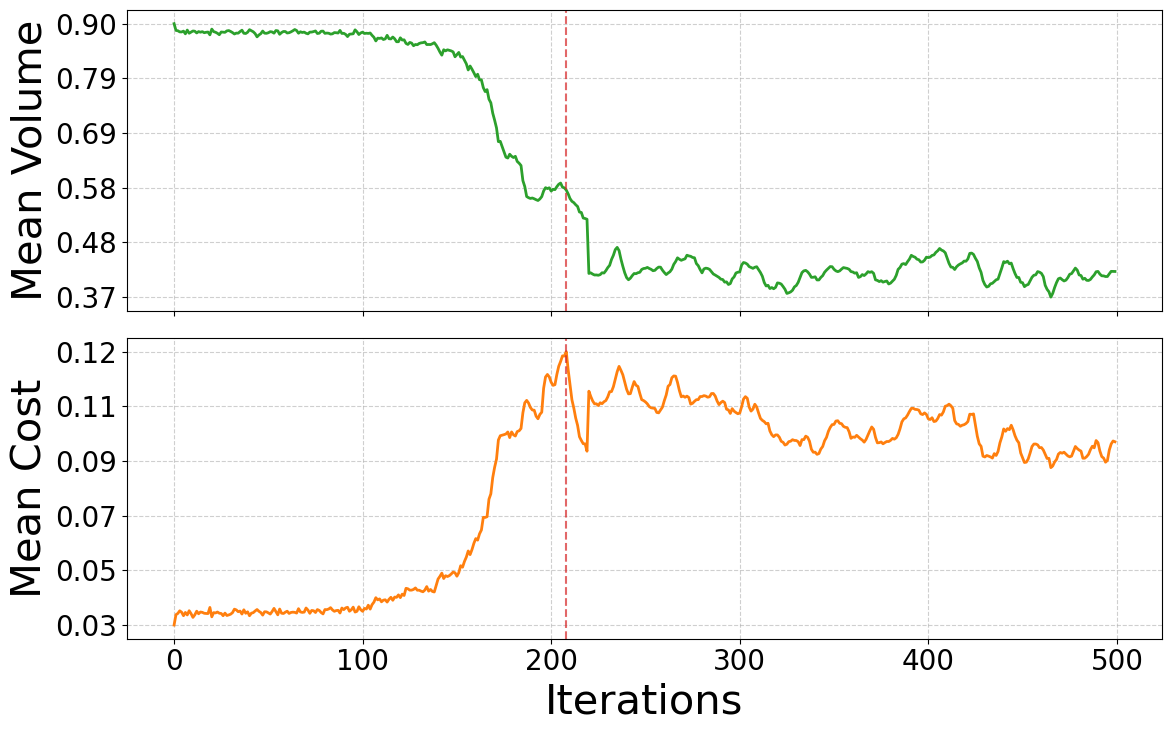

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8),sharex=True)

# Mean Volume Evolution
axs[0].plot(mean_volume, color='tab:green', linewidth=2)
#axs 0].set_title('Mean Volume Evolution')
#axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Mean Volume',fontsize=30)
axs[0].axvline(t_full_loss,c='tab:red',linestyle='--',alpha=0.7)
axs[0].grid(True, linestyle='--', alpha=0.6)
ticks = np.linspace(np.min(mean_volume), np.max(mean_volume), 6)
axs[0].set_yticks(ticks)
axs[0].set_yticklabels([f"{t:.2f}" for t in ticks])
axs[0].tick_params(axis='both')

# Mean Weights Cost Evolution
axs[1].plot(mean_weight_cost, color='tab:orange', linewidth=2)
#axs 1].set_title('Mean Weights Cost Evolution')
axs[1].axvline(t_full_loss,c='tab:red',linestyle='--',alpha=0.7)
axs[1].set_xlabel('Iterations',fontsize=30)
axs[1].set_ylabel('Mean Cost',fontsize=30)
ticks = np.linspace(np.min(mean_weight_cost), np.max(mean_weight_cost), 6)
axs[1].set_yticks(ticks)
axs[1].set_yticklabels([f"{t:.2f}" for t in ticks])
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].tick_params(axis='both')

plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(top=0.92)
plt.savefig('plots/cost.png', dpi=150)
plt.show()


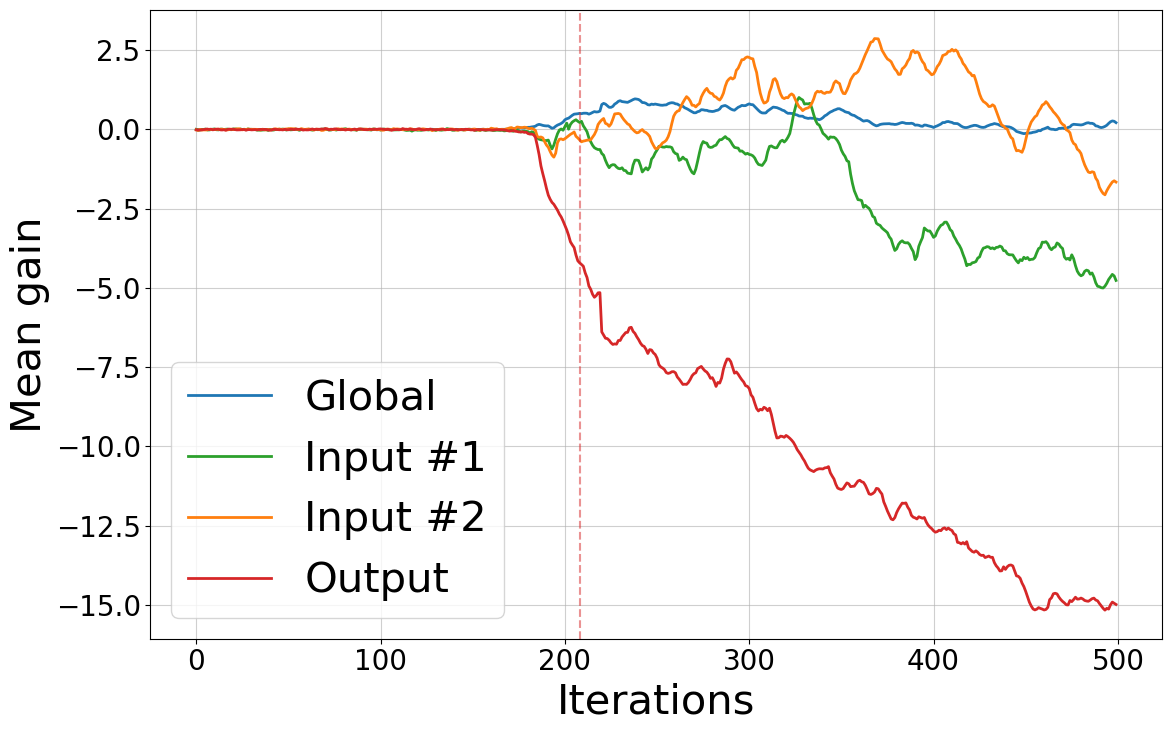

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(np.mean(T_values[:,:-1,:], axis=(0, 1)), color='tab:blue', label='Global', linewidth=2)
plt.plot(np.mean(T_values[:, 2*par['L'], :], axis=0), color='tab:green', label='Input #1', linewidth=2)
plt.plot(np.mean(T_values[:, par['L']//2, :], axis=0), color='tab:orange', label='Input #2', linewidth=2)
plt.plot(np.mean(T_values[:, -1, :], axis=0), color='tab:red', label='Output', linewidth=2)
plt.axvline(t_full_loss,c='tab:red',linestyle='--',alpha=0.5)
#plt.title('Global Mean Gain Parameter')
plt.xlabel('Iterations',fontsize=30)
plt.ylabel('Mean gain',fontsize=30)
plt.grid(True, alpha=0.6)
plt.tick_params(axis='both')
plt.legend(fontsize=30)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(top=0.92)
plt.savefig('plots/gainV2.png', dpi=150)
plt.show()


In [13]:
''' ora non serve
# Prepare mask for highlighting input and output cells
mask = np.zeros((par['L'], par['L']), dtype=bool)
highlight_colors = np.full((par['L'], par['L']), '', dtype=object)

# Highlight input cells (par['L']//2 and 2*par['L']) and output cell (-1)
input_indices = [par['L']//2, 2*par['L']]
output_index = par['L']**2 - 1

for idx in input_indices:
    y, x = divmod(idx, par['L'])
    highlight_colors[y, x] = 'input'
y, x = divmod(output_index, par['L'])
highlight_colors[y, x] = 'output'

# Create a color map for annotations
def highlight_cells(val, color):
    if color == 'input':
        return 'background-color: lightblue'
    elif color == 'output':
        return 'background-color: lightcoral'
    else:
        return ''

data = np.mean(T_values,axis=0)

fig, axes = plt.subplots()
ax = sns.heatmap(
    solutions[n].T.reshape(par['L'], par['L']),
    xticklabels=np.arange(1, par['L']+1),
    yticklabels=np.arange(1, par['L']+1),
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    vmin=np.min(solutions[n].T),
    vmax=np.max(solutions[n].T),
    ax=axes
)

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)


def animate(i):
    plt.clf()
    frame = data.reshape((par['L'], par['L'], -1))[:, :, i]
    ax = sns.heatmap(
        frame,
        xticklabels=np.arange(1, par['L']+1),
        yticklabels=np.arange(1, par['L']+1),
        cmap='coolwarm',
        annot=True,
        fmt=".2f",
        linewidths=.5,
        vmin=-np.max([np.max(solutions[n].T),np.abs(np.min(solutions[n].T))]),
        vmax=np.max([np.max(solutions[n].T),np.abs(np.min(solutions[n].T))])
    )
    ax.set(xlabel="X Coordinate", ylabel="Y Coordinate")
    ax.set_title(f'Mean Gain Parameter Distribution at Iteration {i}')
    ax.xaxis.tick_top()
    for (y, x), label in np.ndenumerate(highlight_colors):
        if label == 'input':
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='deepskyblue', lw=3))
        elif label == 'output':
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=3))

ani = animation.FuncAnimation(fig, animate, frames=data.shape[1], interval=50)

ani.save('plots/gain_map.gif', writer='pillow')
'''

' ora non serve\n# Prepare mask for highlighting input and output cells\nmask = np.zeros((par[\'L\'], par[\'L\']), dtype=bool)\nhighlight_colors = np.full((par[\'L\'], par[\'L\']), \'\', dtype=object)\n\n# Highlight input cells (par[\'L\']//2 and 2*par[\'L\']) and output cell (-1)\ninput_indices = [par[\'L\']//2, 2*par[\'L\']]\noutput_index = par[\'L\']**2 - 1\n\nfor idx in input_indices:\n    y, x = divmod(idx, par[\'L\'])\n    highlight_colors[y, x] = \'input\'\ny, x = divmod(output_index, par[\'L\'])\nhighlight_colors[y, x] = \'output\'\n\n# Create a color map for annotations\ndef highlight_cells(val, color):\n    if color == \'input\':\n        return \'background-color: lightblue\'\n    elif color == \'output\':\n        return \'background-color: lightcoral\'\n    else:\n        return \'\'\n\ndata = np.mean(T_values,axis=0)\n\nfig, axes = plt.subplots()\nax = sns.heatmap(\n    solutions[n].T.reshape(par[\'L\'], par[\'L\']),\n    xticklabels=np.arange(1, par[\'L\']+1),\n    ytick

In [14]:
'''
fig, ax = plt.subplots(figsize=(8, 6))

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Move parameter box to the right and center vertically
fig.text(0.98, 0.5, param_text, fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Use fixed bins for all frames to ensure visibility
bins = np.linspace(np.min(loss_ev), np.max(loss_ev), 50)

def animate(i):
    ax.clear()
    ax.hist(loss_ev[:, i], bins=bins, color='b', alpha=0.7)
    ax.set_title(f'Loss Histogram at Iteration {i+1}')
    ax.set_xlabel('Loss')
    ax.set_ylabel('Population')
    ax.set_xlim(np.min(loss_ev), np.max(loss_ev))
    ax.set_ylim(0, par['N_sol'])

ani = animation.FuncAnimation(fig, animate, frames=loss_ev.shape[1], interval=50)

ani.save('plots/loss_evolution.gif', writer='pillow')
plt.close(fig)
'''

'\nfig, ax = plt.subplots(figsize=(8, 6))\n\nparam_text = (\n    f"L = {par[\'L\']}\n"\n    f"N_sol = {par[\'N_sol\']}\n"\n    f"n_iter = {par[\'n_iter\']}\n"\n    f"C_density = {par[\'C_density\']}\n"\n    f"tau = {par[\'tau\']}\n"\n    f"reproduction_ratio = {par[\'reproduction_ratio\']}\n"\n    f"elitist_ratio = {par[\'elitist_ratio\']}\n"\n    f"ff_iter = {par[\'ff_iter\']}\n"\n    f"J_mutation_radius = {par[\'J_mutation_radius\']}\n"\n    f"B_mutation_radius = {par[\'B_mutation_radius\']}\n"\n    f"T_mutation_radius = {par[\'T_mutation_radius\']}"\n)\n\n# Move parameter box to the right and center vertically\nfig.text(0.98, 0.5, param_text, fontsize=12, va=\'center\', ha=\'right\',\n         bbox=dict(boxstyle=\'round\', facecolor=\'wheat\', alpha=0.5))\n\n# Use fixed bins for all frames to ensure visibility\nbins = np.linspace(np.min(loss_ev), np.max(loss_ev), 50)\n\ndef animate(i):\n    ax.clear()\n    ax.hist(loss_ev[:, i], bins=bins, color=\'b\', alpha=0.7)\n    ax.set_title(f